# Bài tập Học sâu – Tuần 2: Linear Regression & Softmax Regression

**Nội dung notebook**

- **Phần I – Bài tập lý thuyết:** Bài 1 (Linear Regression + GD, thêm L2), Bài 2 (Softmax Regression + GD, thêm L1), Bài 3 (so sánh hai mô hình), Bài 4 (ảnh hưởng của λ).
- **Phần II – Bài tập thực hành:** lập trình từ đầu Linear Regression **chỉ dùng Python và NumPy** (matplotlib chỉ để vẽ), huấn luyện trên bộ dữ liệu **California Housing**, vẽ và phân tích kết quả.

Ký hiệu theo Bài giảng 2 của môn. Chỗ nào ngoài bài giảng được ghi rõ *(ngoài bài giảng)*.

# PHẦN I – BÀI TẬP LÝ THUYẾT

## Quy ước ký hiệu

Các ký hiệu dùng theo Bài giảng 2 (Hồi quy tuyến tính và Hồi quy Softmax):

- Tập huấn luyện $D = \{(\mathbf{x}_i, y_i)\}_{i=1}^{n}$, mỗi $\mathbf{x}_i \in \mathbb{R}^d$ ($d$ đặc trưng). Khi viết theo mẫu, ta dùng $\mathbf{x}^{(i)}, y^{(i)}, \hat y^{(i)}, l^{(i)}$ như trong bài giảng.
- $\eta$: learning rate; $\lambda \ge 0$: hệ số regularization.
- $m$: batch size (số mẫu dùng cho 1 lần cập nhật), $m < n$. $\mathcal{B} \subset \{1,\dots,n\}$ là tập chỉ số của một batch, $|\mathcal{B}| = m$.
- $\mathbf{X}_\mathcal{B} \in \mathbb{R}^{m\times d}$: ma trận đầu vào của batch (mỗi hàng là một mẫu); $\mathbf{y}_\mathcal{B} \in \mathbb{R}^m$: nhãn của batch.
- **Epoch**: một lần duyệt qua toàn bộ dữ liệu huấn luyện. **Iterations**: số batch cần duyệt trong 1 epoch, bằng $\lceil n/m \rceil$.

Cả 4 bài dùng cùng khung vòng huấn luyện trong bài giảng: **Initialize → Tính $\hat y$ → Tính Loss → Tính Gradient → Update**, lặp lại cho mỗi batch.

## Bài 1. Linear Regression với Gradient Descent

### Bài 1a. Thuật toán huấn luyện

**Mô hình:** $\hat y = \mathbf{w}^\top \mathbf{x} + b$, với $\mathbf{w} \in \mathbb{R}^d$, $b \in \mathbb{R}$. Tham số cần học là $\theta = (\mathbf{w}, b)$.

**Hàm loss trên một mẫu (Squared Error):**
$$l^{(i)} = \frac{1}{2}\left(\hat y^{(i)} - y^{(i)}\right)^2$$

**Hàm loss trên một batch $m$ mẫu:**
$$L_\mathcal{B}(\mathbf{w}, b) = \frac{1}{m}\sum_{i\in\mathcal{B}} l^{(i)} = \frac{1}{2m}\sum_{i\in\mathcal{B}}\left(\hat y^{(i)} - y^{(i)}\right)^2$$

**Suy ra gradient (chain rule):** đặt $e^{(i)} = \hat y^{(i)} - y^{(i)}$. Khi đó
$$\frac{\partial l^{(i)}}{\partial w_j} = \frac{\partial l^{(i)}}{\partial \hat y^{(i)}}\cdot\frac{\partial \hat y^{(i)}}{\partial w_j} = \left(\hat y^{(i)} - y^{(i)}\right)x_j^{(i)}, \qquad \frac{\partial l^{(i)}}{\partial b} = \hat y^{(i)} - y^{(i)}$$

Lấy trung bình trên batch và viết dạng véc-tơ:
$$\frac{\partial L_\mathcal{B}}{\partial \mathbf{w}} = \frac{1}{m}\sum_{i\in\mathcal{B}}\left(\hat y^{(i)} - y^{(i)}\right)\mathbf{x}^{(i)} = \frac{1}{m}\mathbf{X}_\mathcal{B}^\top\left(\hat{\mathbf{y}}_\mathcal{B} - \mathbf{y}_\mathcal{B}\right), \qquad \frac{\partial L_\mathcal{B}}{\partial b} = \frac{1}{m}\sum_{i\in\mathcal{B}}\left(\hat y^{(i)} - y^{(i)}\right)$$

**Thuật toán 1: Mini-batch Gradient Descent cho Linear Regression**

**Đầu vào:** $D$, learning rate $\eta$, batch size $m$, số epoch $E$.

1. **Initialize:** $\mathbf{w} \leftarrow \mathbf{0} \in \mathbb{R}^d$ (hoặc số ngẫu nhiên nhỏ), $b \leftarrow 0$.
2. **Lặp** với epoch $= 1, \dots, E$:
    1. Xáo trộn ngẫu nhiên thứ tự $n$ mẫu, rồi chia thành các batch $\mathcal{B}$, mỗi batch $m$ mẫu.
    2. **Với mỗi batch $\mathcal{B}$:**
        - (a) **Tính $\hat y$:** $\hat y^{(i)} = \mathbf{w}^\top\mathbf{x}^{(i)} + b$ với mọi $i \in \mathcal{B}$. Dạng ma trận: $\hat{\mathbf{y}}_\mathcal{B} = \mathbf{X}_\mathcal{B}\mathbf{w} + b$.
        - (b) **Tính Loss:** $L_\mathcal{B} = \dfrac{1}{2m}\displaystyle\sum_{i\in\mathcal{B}}\left(\hat y^{(i)} - y^{(i)}\right)^2$.
        - (c) **Tính Gradient:** $\mathbf{g}_\mathbf{w} = \dfrac{1}{m}\mathbf{X}_\mathcal{B}^\top(\hat{\mathbf{y}}_\mathcal{B} - \mathbf{y}_\mathcal{B})$, $\;g_b = \dfrac{1}{m}\displaystyle\sum_{i\in\mathcal{B}}(\hat y^{(i)} - y^{(i)})$.
        - (d) **Update:** $\mathbf{w} \leftarrow \mathbf{w} - \eta\,\mathbf{g}_\mathbf{w}$, $\;b \leftarrow b - \eta\, g_b$.
3. **Trả về** $\mathbf{w}, b$.

**Nhận xét:**

- Khi $m = 1$, công thức trở về dạng cập nhật trên một mẫu trong bài giảng: $\mathbf{w} \leftarrow \mathbf{w} - \eta(\hat y^{(i)} - y^{(i)})\mathbf{x}^{(i)}$. Khi $m = n$, ta được công thức cập nhật trên toàn bộ tập huấn luyện.
- Hệ số $\frac{1}{m}$ giúp độ lớn gradient không phụ thuộc vào batch size, nên có thể giữ nguyên $\eta$ khi đổi $m$.

### Bài 1b. Bổ sung L2 vào hàm loss

**Hàm loss mới** (dạng giống bài giảng, phạt L2 với hệ số $\frac{\lambda}{2}$, không phạt bias):
$$J_\mathcal{B}(\mathbf{w}, b) = \frac{1}{2m}\sum_{i\in\mathcal{B}}\left(\hat y^{(i)} - y^{(i)}\right)^2 + \frac{\lambda}{2}\sum_{j=1}^{d} w_j^2 = L_\mathcal{B} + \frac{\lambda}{2}\|\mathbf{w}\|_2^2$$

**Gradient:** số hạng phạt chỉ phụ thuộc $\mathbf{w}$, và $\dfrac{\partial}{\partial w_j}\left(\dfrac{\lambda}{2}\displaystyle\sum_k w_k^2\right) = \lambda w_j$. Do đó
$$\frac{\partial J_\mathcal{B}}{\partial \mathbf{w}} = \frac{1}{m}\mathbf{X}_\mathcal{B}^\top(\hat{\mathbf{y}}_\mathcal{B} - \mathbf{y}_\mathcal{B}) + \lambda\mathbf{w}, \qquad \frac{\partial J_\mathcal{B}}{\partial b} = \frac{1}{m}\sum_{i\in\mathcal{B}}(\hat y^{(i)} - y^{(i)}) \;\;(\text{không đổi})$$

**Thuật toán 1b: Mini-batch GD cho Linear Regression + L2**

1. **Initialize:** $\mathbf{w} \leftarrow \mathbf{0}$, $b \leftarrow 0$; chọn $\eta$, $m$, $E$, $\lambda \ge 0$.
2. **Lặp** qua các epoch; mỗi epoch xáo trộn dữ liệu rồi, **với mỗi batch $\mathcal{B}$:**
    - (a) **Tính $\hat y$:** $\hat{\mathbf{y}}_\mathcal{B} = \mathbf{X}_\mathcal{B}\mathbf{w} + b$.
    - (b) **Tính Loss:** $J_\mathcal{B} = \dfrac{1}{2m}\|\hat{\mathbf{y}}_\mathcal{B} - \mathbf{y}_\mathcal{B}\|^2 + \dfrac{\lambda}{2}\|\mathbf{w}\|_2^2$.
    - (c) **Tính Gradient:** $\mathbf{g}_\mathbf{w} = \dfrac{1}{m}\mathbf{X}_\mathcal{B}^\top(\hat{\mathbf{y}}_\mathcal{B} - \mathbf{y}_\mathcal{B}) + \lambda\mathbf{w}$, $\;g_b = \dfrac{1}{m}\displaystyle\sum_{i\in\mathcal{B}}(\hat y^{(i)} - y^{(i)})$.
    - (d) **Update:** $\mathbf{w} \leftarrow \mathbf{w} - \eta\,\mathbf{g}_\mathbf{w}$, $\;b \leftarrow b - \eta\,g_b$.
3. **Trả về** $\mathbf{w}, b$.

**Nhận xét:** viết lại bước Update của $\mathbf{w}$:
$$\mathbf{w} \leftarrow (1 - \eta\lambda)\,\mathbf{w} - \frac{\eta}{m}\mathbf{X}_\mathcal{B}^\top(\hat{\mathbf{y}}_\mathcal{B} - \mathbf{y}_\mathcal{B})$$

Mỗi bước, $\mathbf{w}$ bị nhân với hệ số $(1-\eta\lambda) < 1$ nên bị kéo dần về 0. Đây chính là **weight decay** được nhắc tới trong bài giảng. Cần chọn $\eta\lambda < 1$, nếu không hệ số này đổi dấu và quá trình huấn luyện mất ổn định.

## Bài 2. Softmax Regression với Gradient Descent

### Bài 2a. Thuật toán huấn luyện

**Mô hình ($q$ lớp):** $\mathbf{W} = [\mathbf{w}_1\ \mathbf{w}_2 \cdots \mathbf{w}_q] \in \mathbb{R}^{d\times q}$, $\mathbf{b} \in \mathbb{R}^q$.

- Logit: $\mathbf{o} = \mathbf{W}^\top\mathbf{x} + \mathbf{b}$, tức $o_j = \mathbf{w}_j^\top\mathbf{x} + b_j$.
- Xác suất: $\hat y_j = \text{softmax}(\mathbf{o})_j = \dfrac{\exp(o_j)}{\sum_{k=1}^{q}\exp(o_k)}$.
- Nhãn $y_i \in \{1,\dots,q\}$ được biểu diễn bằng véc-tơ one-hot $\mathbf{y}^{(i)} \in \{0,1\}^q$.

Với cả batch: $\mathbf{O}_\mathcal{B} = \mathbf{X}_\mathcal{B}\mathbf{W} + \mathbf{b} \in \mathbb{R}^{m\times q}$ ($\mathbf{b}$ được cộng vào từng hàng); $\hat{\mathbf{Y}}_\mathcal{B}$ là softmax theo từng hàng của $\mathbf{O}_\mathcal{B}$; $\mathbf{Y}_\mathcal{B} \in \{0,1\}^{m\times q}$ là ma trận nhãn one-hot.

**Hàm loss (Cross-Entropy) trên batch:**
$$L_\mathcal{B}(\mathbf{W}, \mathbf{b}) = \frac{1}{m}\sum_{i\in\mathcal{B}} l^{(i)} = -\frac{1}{m}\sum_{i\in\mathcal{B}}\sum_{j=1}^{q} y_j^{(i)}\log\hat y_j^{(i)}$$

**Gradient** (theo kết quả trong bài giảng: $\dfrac{\partial l}{\partial o_j} = \hat y_j - y_j$, $\dfrac{\partial l}{\partial \mathbf{w}_j} = (\hat y_j - y_j)\mathbf{x}$, $\dfrac{\partial l}{\partial b_j} = \hat y_j - y_j$). Lấy trung bình trên batch và viết dạng ma trận:
$$\frac{\partial L_\mathcal{B}}{\partial \mathbf{W}} = \frac{1}{m}\mathbf{X}_\mathcal{B}^\top(\hat{\mathbf{Y}}_\mathcal{B} - \mathbf{Y}_\mathcal{B}) \in \mathbb{R}^{d\times q}, \qquad \frac{\partial L_\mathcal{B}}{\partial \mathbf{b}} = \frac{1}{m}\sum_{i\in\mathcal{B}}\left(\hat{\mathbf{y}}^{(i)} - \mathbf{y}^{(i)}\right) \in \mathbb{R}^{q}$$

Kiểm tra kích thước: $\mathbf{X}_\mathcal{B}^\top$ có kích thước $d\times m$, $(\hat{\mathbf{Y}}_\mathcal{B} - \mathbf{Y}_\mathcal{B})$ có kích thước $m\times q$, nên tích có kích thước $d\times q$, đúng bằng kích thước của $\mathbf{W}$.

**Thuật toán 2: Mini-batch Gradient Descent cho Softmax Regression**

**Đầu vào:** $D$, số lớp $q$, $\eta$, $m$, $E$.

1. **Initialize:** $\mathbf{W} \leftarrow \mathbf{0} \in \mathbb{R}^{d\times q}$ (hoặc ngẫu nhiên nhỏ), $\mathbf{b} \leftarrow \mathbf{0} \in \mathbb{R}^q$; chuyển nhãn sang one-hot.
2. **Lặp** qua các epoch; mỗi epoch xáo trộn dữ liệu rồi, **với mỗi batch $\mathcal{B}$:**
    - (a) **Tính $\hat y$:**
        - Logit: $\mathbf{O}_\mathcal{B} = \mathbf{X}_\mathcal{B}\mathbf{W} + \mathbf{b}$.
        - Softmax ổn định (theo bài giảng): với mỗi mẫu $i$, đặt $c^{(i)} = \max_k o_k^{(i)}$, rồi tính $\hat y_j^{(i)} = \dfrac{\exp(o_j^{(i)} - c^{(i)})}{\sum_{k}\exp(o_k^{(i)} - c^{(i)})}$.
    - (b) **Tính Loss:** $L_\mathcal{B} = -\dfrac{1}{m}\displaystyle\sum_{i\in\mathcal{B}}\sum_{j=1}^{q} y_j^{(i)}\log\hat y_j^{(i)}$.
    - (c) **Tính Gradient:** $\mathbf{G}_\mathbf{W} = \dfrac{1}{m}\mathbf{X}_\mathcal{B}^\top(\hat{\mathbf{Y}}_\mathcal{B} - \mathbf{Y}_\mathcal{B})$, $\;\mathbf{g}_\mathbf{b} = \dfrac{1}{m}\displaystyle\sum_{i\in\mathcal{B}}(\hat{\mathbf{y}}^{(i)} - \mathbf{y}^{(i)})$.
    - (d) **Update:** $\mathbf{W} \leftarrow \mathbf{W} - \eta\,\mathbf{G}_\mathbf{W}$, $\;\mathbf{b} \leftarrow \mathbf{b} - \eta\,\mathbf{g}_\mathbf{b}$.
3. **Dự đoán:** $\hat y = \arg\max_j \hat y_j = \arg\max_j o_j$ (softmax giữ nguyên thứ tự các logit).

**Nhận xét:** khi $m = 1$, bước Update trở về dạng ma trận trên một mẫu trong bài giảng: $\mathbf{W} \leftarrow \mathbf{W} - \eta\,\mathbf{x}(\hat{\mathbf{y}} - \mathbf{y})^\top$, $\;\mathbf{b} \leftarrow \mathbf{b} - \eta(\hat{\mathbf{y}} - \mathbf{y})$.

### Bài 2b. Bổ sung L1 vào hàm loss

**Hàm loss mới** (dạng L1 trong bài giảng, $J = L + \lambda\sum|w|$, không phạt bias):
$$J_\mathcal{B}(\mathbf{W}, \mathbf{b}) = -\frac{1}{m}\sum_{i\in\mathcal{B}}\sum_{j=1}^{q} y_j^{(i)}\log\hat y_j^{(i)} + \lambda\sum_{k=1}^{d}\sum_{j=1}^{q}|W_{kj}|$$

**Gradient của số hạng L1** *(phần này ngoài bài giảng; bài giảng chỉ nêu dạng hàm loss L1, chưa nêu đạo hàm)*: hàm $|w|$ có đạo hàm bằng $+1$ khi $w > 0$ và $-1$ khi $w < 0$, nhưng không khả vi tại $w = 0$. Người ta dùng **đạo hàm con (subgradient)** $\text{sign}(w)$, với quy ước $\text{sign}(0) = 0$:
$$\frac{\partial}{\partial W_{kj}}\lambda|W_{kj}| = \lambda\,\text{sign}(W_{kj})$$

Do đó
$$\frac{\partial J_\mathcal{B}}{\partial \mathbf{W}} = \frac{1}{m}\mathbf{X}_\mathcal{B}^\top(\hat{\mathbf{Y}}_\mathcal{B} - \mathbf{Y}_\mathcal{B}) + \lambda\,\text{sign}(\mathbf{W}), \qquad \frac{\partial J_\mathcal{B}}{\partial \mathbf{b}} = \frac{1}{m}\sum_{i\in\mathcal{B}}(\hat{\mathbf{y}}^{(i)} - \mathbf{y}^{(i)}) \;\;(\text{không đổi})$$

($\text{sign}(\mathbf{W})$ lấy dấu của từng phần tử của $\mathbf{W}$.)

**Thuật toán 2b: Mini-batch GD cho Softmax Regression + L1**

1. **Initialize:** $\mathbf{W} \leftarrow \mathbf{0}$, $\mathbf{b} \leftarrow \mathbf{0}$; chọn $\eta$, $m$, $E$, $\lambda \ge 0$.
2. **Lặp** qua các epoch; mỗi epoch xáo trộn dữ liệu rồi, **với mỗi batch $\mathcal{B}$:**
    - (a) **Tính $\hat y$:** $\mathbf{O}_\mathcal{B} = \mathbf{X}_\mathcal{B}\mathbf{W} + \mathbf{b}$; $\hat{\mathbf{Y}}_\mathcal{B} = \text{softmax}(\mathbf{O}_\mathcal{B})$ theo hàng (trừ max để ổn định).
    - (b) **Tính Loss:** $J_\mathcal{B} = -\dfrac{1}{m}\displaystyle\sum_{i\in\mathcal{B}}\sum_{j} y_j^{(i)}\log\hat y_j^{(i)} + \lambda\sum_{k,j}|W_{kj}|$.
    - (c) **Tính Gradient:** $\mathbf{G}_\mathbf{W} = \dfrac{1}{m}\mathbf{X}_\mathcal{B}^\top(\hat{\mathbf{Y}}_\mathcal{B} - \mathbf{Y}_\mathcal{B}) + \lambda\,\text{sign}(\mathbf{W})$, $\;\mathbf{g}_\mathbf{b} = \dfrac{1}{m}\displaystyle\sum_{i\in\mathcal{B}}(\hat{\mathbf{y}}^{(i)} - \mathbf{y}^{(i)})$.
    - (d) **Update:** $\mathbf{W} \leftarrow \mathbf{W} - \eta\,\mathbf{G}_\mathbf{W}$, $\;\mathbf{b} \leftarrow \mathbf{b} - \eta\,\mathbf{g}_\mathbf{b}$.

**Nhận xét:**

- Số hạng $\lambda\,\text{sign}(\mathbf{W})$ đẩy mỗi trọng số về 0 một lượng cố định $\eta\lambda$ ở mỗi bước, bất kể trọng số lớn hay nhỏ. Với L2, lượng đẩy là $\eta\lambda w$, tỉ lệ với $w$ và nhỏ dần khi $w$ gần 0. Vì vậy L1 làm nhiều trọng số về 0 (khớp với bài giảng: "khuyến khích nhiều weight trở thành 0", "có thể thực hiện feature selection"), còn L2 "thường không làm weight bằng chính xác 0".
- *(Ngoài bài giảng)* Với subgradient thuần, trọng số thường dao động quanh 0 thay vì bằng đúng 0. Muốn ra đúng 0, người ta dùng biến thể proximal gradient (soft-thresholding), không bắt buộc trong bài này.

## Bài 3. So sánh hai mô hình A và B

**Kết luận: Không.** Không thể kết luận A tốt hơn B chỉ dựa vào training loss.

**Giải thích:**

1. **Mục tiêu thực sự** của học máy là làm nhỏ **rủi ro kỳ vọng** $R(f_\theta)$, tức sai số trên dữ liệu mới lấy từ phân phối $P(\mathbf{x}, y)$. Training loss chỉ là **rủi ro thực nghiệm** $\hat R(f_\theta)$ trên chính dữ liệu đã dùng để học. Theo bài giảng, một mô hình tốt cần **cả** $R(f_\theta)$ **và** $\hat R(f_\theta)$ nhỏ, và mục tiêu không chỉ là cực tiểu $\hat R$.
2. **Test loss** được tính trên dữ liệu mô hình chưa thấy, nên là ước lượng của $R(f_\theta)$, tức khả năng tổng quát hóa.
3. **Trường hợp này:** A có training loss thấp hơn B nhưng test loss cao hơn B. Đây đúng là dấu hiệu **overfitting** theo bài giảng: $\hat R(f_\theta)$ nhỏ nhưng $R(f_\theta)$ lại cao. A có thể đã học cả **nhiễu** và các đặc điểm chỉ tồn tại trong tập huấn luyện (theo góc nhìn bias–variance: A có variance cao hơn).
4. Vì vậy, xét theo khả năng dự đoán trên dữ liệu mới, **B tốt hơn A**.

**Lưu ý thêm** *(ngoài bài giảng)*: phép so sánh chỉ hợp lệ khi A và B được đánh giá trên **cùng một** tập test độc lập với dữ liệu huấn luyện. Nếu chênh lệch test loss rất nhỏ, nên kiểm tra thêm (vd. dùng tập validation hoặc lặp lại với nhiều cách chia dữ liệu) trước khi kết luận chắc chắn.

## Bài 4. Phân tích ảnh hưởng của λ trong L = L_data + (λ/2)‖w‖²

**Cơ chế chung:** gradient là $\nabla L = \nabla L_\text{data} + \lambda\mathbf{w}$, nên bước cập nhật là $\mathbf{w} \leftarrow (1 - \eta\lambda)\mathbf{w} - \eta\nabla L_\text{data}$. $\lambda$ càng lớn thì trọng số càng bị kéo mạnh về 0, làm mô hình đơn giản hơn (độ phức tạp thấp hơn).

### Trường hợp 1: λ = 0

- **Độ lớn weight:** không có thành phần nào ngăn $\mathbf{w}$ trở nên quá lớn, nên $\mathbf{w}$ có thể rất lớn (nhất là khi dữ liệu ít hoặc số feature lớn).
- **Training error:** thấp nhất trong 3 trường hợp, vì mô hình chỉ tối ưu $L_\text{data}$.
- **Overfitting/Underfitting:** dễ **overfitting** nhất. Mô hình có thể fit quá sát training data, dẫn tới test error cao.
- **Bias – Variance:** bias thấp, **variance cao**. Mô hình nhạy với những thay đổi nhỏ hoặc nhiễu trong dữ liệu.

### Trường hợp 2: λ vừa phải

- **Độ lớn weight:** được thu nhỏ ở mức vừa phải. Các trọng số quan trọng vẫn giữ giá trị đáng kể, các trọng số ít quan trọng bị kéo gần 0 (L2 thường không làm weight bằng đúng 0).
- **Training error:** cao hơn một chút so với $\lambda = 0$, vì mô hình không còn chỉ tối ưu $L_\text{data}$.
- **Overfitting/Underfitting:** giảm overfitting; test error thường **thấp nhất**, tức mô hình tổng quát hóa tốt nhất.
- **Bias – Variance:** bias tăng nhẹ, variance giảm đáng kể. Mô hình đạt **cân bằng** giữa hai trạng thái, ứng với vùng "optimal capacity" trên biểu đồ model complexity.

### Trường hợp 3: λ rất lớn

- **Độ lớn weight:** số hạng phạt chiếm ưu thế nên $\mathbf{w} \to \mathbf{0}$. Vì bias $b$ không bị phạt, mô hình gần như thành **mô hình hằng số** $\hat y \approx b$ (chỉ dự đoán giá trị trung bình).
- **Training error:** **cao**, test error cũng cao.
- **Overfitting/Underfitting:** **underfitting**. Mô hình quá đơn giản, không mô tả được xu hướng của dữ liệu ($R$ và $\hat R$ đều cao).
- **Bias – Variance:** **bias cao**, variance thấp. Đây là trường hợp mô hình hằng số trong bài giảng: ổn định (Variance ≈ 0) nhưng không chính xác.

### Tổng kết

| Tiêu chí | $\lambda = 0$ | $\lambda$ vừa phải | $\lambda$ rất lớn |
|---|---|---|---|
| Độ lớn weight | Lớn, không bị kiểm soát | Vừa phải, thu nhỏ | Gần 0 |
| Training error | Thấp nhất | Hơi cao hơn | Cao |
| Test error | Có thể cao (nếu overfit) | Thấp nhất | Cao |
| Tình trạng | Dễ overfitting | Cân bằng | Underfitting |
| Bias | Thấp | Trung bình | Cao |
| Variance | Cao | Trung bình | Thấp |

*Bảng 1. So sánh ảnh hưởng của λ trong L2 regularization*

*Ghi chú:* ở trường hợp $\lambda = 0$, overfitting xảy ra rõ khi mô hình đủ phức tạp so với lượng dữ liệu. Nếu dữ liệu rất nhiều và mô hình đơn giản, chênh lệch giữa ba trường hợp nhỏ hơn. Phần thực hành (mục 8 bên dưới) minh họa trực tiếp ba trường hợp này bằng số liệu thật.

# PHẦN II – BÀI TẬP THỰC HÀNH

**Đề bài:** Lập trình từ đầu cho mô hình Linear Regression chỉ sử dụng Python và NumPy. Huấn luyện mô hình này trên một bộ dữ liệu bất kỳ, vẽ và phân tích kết quả.

**Kế hoạch**

1. Nạp và khám phá dữ liệu California Housing
2. Tiền xử lý: điền giá trị thiếu, one-hot, chia train/val/test, chuẩn hóa
3. Cài đặt lớp `LinearRegressionGD` theo khung *Initialize → Tính ŷ → Tính Loss → Tính Gradient → Update*
4. Kiểm tra tính đúng của code (gradient check, dữ liệu giả lập, so với nghiệm đóng)
5. Huấn luyện mô hình chính và đánh giá
6. Vẽ và phân tích kết quả dự đoán
7. Thí nghiệm: ảnh hưởng của learning rate η và batch size m
8. Thí nghiệm: ảnh hưởng của L2 regularization λ (minh họa Bài 4)
9. Tổng kết

## 0. Thư viện

- `numpy`: toàn bộ phần mô hình và tính toán.
- `matplotlib`: chỉ dùng để vẽ.
- `csv`, `os`, `urllib`, `time`: thư viện chuẩn của Python, dùng để đọc file, tải dữ liệu và đo thời gian.

In [1]:
import csv
import os
import time
import urllib.request

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter, FixedFormatter

# Cố định seed để kết quả chạy lại giống nhau
SEED = 42
np.random.seed(SEED)

plt.rcParams["figure.dpi"] = 100
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
print("NumPy version:", np.__version__)


def oxy_axes(ax, origin=True):
    """Vẽ hai trục giống hệ trục Oxy trong toán học.

    - Bỏ khung trên và khung phải, chỉ giữ trục hoành và trục tung vuông góc, có mũi tên.
    - origin=True : hai trục cắt nhau tại gốc O(0, 0), chỉ ghi MỘT số 0 ở gốc.
        + Nếu dữ liệu không âm, khung hình bắt đầu đúng từ 0 -> gốc O nằm ở góc dưới-trái.
        + Nếu dữ liệu có giá trị âm, hai trục cắt nhau bên trong hình (như Oxy khi có số âm).
    - origin=False: dùng cho hình không có số 0 có nghĩa (bản đồ kinh/vĩ độ, trục là tên
      đặc trưng). Hai trục vẫn vuông góc, có mũi tên, gặp nhau ở góc dưới-trái.

    Gọi hàm SAU KHI đã vẽ xong dữ liệu và đặt giới hạn trục (nếu có).
    """
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    for side in ("left", "bottom"):
        ax.spines[side].set_linewidth(1.2)
        ax.spines[side].set_zorder(5)

    if not origin:
        # Mũi tên ở cuối hai trục (tọa độ theo khung hình: 0 = trái/dưới, 1 = phải/trên)
        ax.plot(1, 0, ">k", ms=7, transform=ax.transAxes, clip_on=False, zorder=6)
        ax.plot(0, 1, "^k", ms=7, transform=ax.transAxes, clip_on=False, zorder=6)
        return

    # (1) Đưa gốc 0 vào khung hình.
    #     Trục nào matplotlib đang tự co giãn và dữ liệu không âm -> bắt đầu đúng từ 0
    #     (bỏ phần lề âm nhỏ mà matplotlib tự thêm vào).
    x0, x1 = ax.get_xlim()
    y0, y1 = ax.get_ylim()
    if ax.get_autoscalex_on() and ax.dataLim.x0 >= 0:
        x0 = 0
    if ax.get_autoscaley_on() and ax.dataLim.y0 >= 0:
        y0 = 0
    ax.set_xlim(min(x0, 0), max(x1, 0))
    ax.set_ylim(min(y0, 0), max(y1, 0))

    # (2) Cho hai trục đi qua gốc O(0, 0)
    ax.spines["left"].set_position(("data", 0))
    ax.spines["bottom"].set_position(("data", 0))

    # (3) Bỏ số 0 riêng của từng trục, chỉ ghi một số 0 ở gốc (góc dưới-trái của O)
    def hide_zero(v, pos, base):
        if abs(v) < 1e-12:
            return ""
        if isinstance(base, FixedFormatter):          # nhãn tự đặt, vd các giá trị λ
            return base(v, pos)
        return f"{v:g}".replace("-", "−")
    for axis in (ax.xaxis, ax.yaxis):
        base = axis.get_major_formatter()
        axis.set_major_formatter(FuncFormatter(lambda v, pos, b=base: hide_zero(v, pos, b)))
    ax.annotate("0", xy=(0, 0), xytext=(-4, -4), textcoords="offset points",
                ha="right", va="top", fontsize=plt.rcParams["xtick.labelsize"])

    # (4) Mũi tên ở cuối hai trục
    #     get_yaxis_transform: x theo khung hình (1 = mép phải), y theo dữ liệu (y = 0)
    ax.plot(1, 0, ">k", ms=7, transform=ax.get_yaxis_transform(), clip_on=False, zorder=6)
    ax.plot(0, 1, "^k", ms=7, transform=ax.get_xaxis_transform(), clip_on=False, zorder=6)

    # (5) Nếu trục cắt nhau bên trong hình, đặt tên trục ra mép khung để không đè lên dữ liệu
    if ax.get_ylim()[0] < 0:
        ax.xaxis.set_label_coords(0.5, -0.07)
    if ax.get_xlim()[0] < 0:
        ax.yaxis.set_label_coords(-0.09, 0.5)


NumPy version: 2.4.6


## 1. Nạp và khám phá dữ liệu

**Bộ dữ liệu California Housing** (điều tra dân số California năm 1990): mỗi dòng là một khu dân cư (block group), gồm 20.640 dòng.

| Cột | Ý nghĩa |
|---|---|
| `longitude`, `latitude` | Kinh độ, vĩ độ |
| `housing_median_age` | Tuổi trung vị của nhà trong khu |
| `total_rooms`, `total_bedrooms` | Tổng số phòng, tổng số phòng ngủ |
| `population`, `households` | Dân số, số hộ gia đình |
| `median_income` | Thu nhập trung vị (đơn vị: 10.000 USD) |
| `ocean_proximity` | Vị trí so với biển (dạng chữ) |
| **`median_house_value`** | **Giá nhà trung vị (USD) – biến mục tiêu $y$** |

File `housing.csv` lấy từ kho GitHub của sách *Hands-On Machine Learning* (A. Géron). Nếu chưa có file, code sẽ tự tải về cùng thư mục với notebook (chỉ cần tải 1 lần).

In [2]:
DATA_URL = "https://raw.githubusercontent.com/ageron/handson-ml2/master/datasets/housing/housing.csv"
DATA_PATH = "housing.csv"

# Tải file nếu chưa có
if not os.path.exists(DATA_PATH):
    print("Đang tải dữ liệu...")
    urllib.request.urlretrieve(DATA_URL, DATA_PATH)

# Đọc file CSV bằng module csv chuẩn
with open(DATA_PATH, encoding="utf-8") as f:
    rows = list(csv.reader(f))

header = rows[0]
body = rows[1:]
print("Các cột:", header)
print("Số dòng dữ liệu:", len(body))

Các cột: ['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income', 'median_house_value', 'ocean_proximity']
Số dòng dữ liệu: 20640


In [3]:
# 9 cột đầu là số, cột cuối (ocean_proximity) là chữ
numeric_names = header[:9]

# Ô trống -> np.nan
numeric_data = np.array(
    [[float(v) if v != "" else np.nan for v in r[:9]] for r in body]
)
ocean = np.array([r[9] for r in body])

target_idx = numeric_names.index("median_house_value")
feature_names = [c for c in numeric_names if c != "median_house_value"]

X_num = np.delete(numeric_data, target_idx, axis=1)   # 8 đặc trưng số
y_all = numeric_data[:, target_idx]                   # giá nhà (USD)

print("X_num:", X_num.shape, " y:", y_all.shape)
print("\nSố giá trị thiếu mỗi cột:")
for name, cnt in zip(feature_names, np.isnan(X_num).sum(axis=0)):
    print(f"  {name:20s}: {cnt}")

X_num: (20640, 8)  y: (20640,)

Số giá trị thiếu mỗi cột:
  longitude           : 0
  latitude            : 0
  housing_median_age  : 0
  total_rooms         : 0
  total_bedrooms      : 207
  population          : 0
  households          : 0
  median_income       : 0


In [4]:
# Thống kê mô tả các cột số
print(f"{'Cột':22s}{'min':>12s}{'mean':>12s}{'median':>12s}{'max':>12s}")
for name, col in zip(feature_names + ["median_house_value"],
                     np.column_stack([X_num, y_all]).T):
    print(f"{name:22s}{np.nanmin(col):12.2f}{np.nanmean(col):12.2f}"
          f"{np.nanmedian(col):12.2f}{np.nanmax(col):12.2f}")

# Phân bố cột chữ ocean_proximity
cats, counts = np.unique(ocean, return_counts=True)
print("\nocean_proximity:")
for c, k in zip(cats, counts):
    print(f"  {c:12s}: {k}")

Cột                            min        mean      median         max
longitude                  -124.35     -119.57     -118.49     -114.31
latitude                     32.54       35.63       34.26       41.95
housing_median_age            1.00       28.64       29.00       52.00
total_rooms                   2.00     2635.76     2127.00    39320.00
total_bedrooms                1.00      537.87      435.00     6445.00
population                    3.00     1425.48     1166.00    35682.00
households                    1.00      499.54      409.00     6082.00
median_income                 0.50        3.87        3.53       15.00
median_house_value        14999.00   206855.82   179700.00   500001.00

ocean_proximity:
  <1H OCEAN   : 9136
  INLAND      : 6551
  ISLAND      : 5
  NEAR BAY    : 2290
  NEAR OCEAN  : 2658


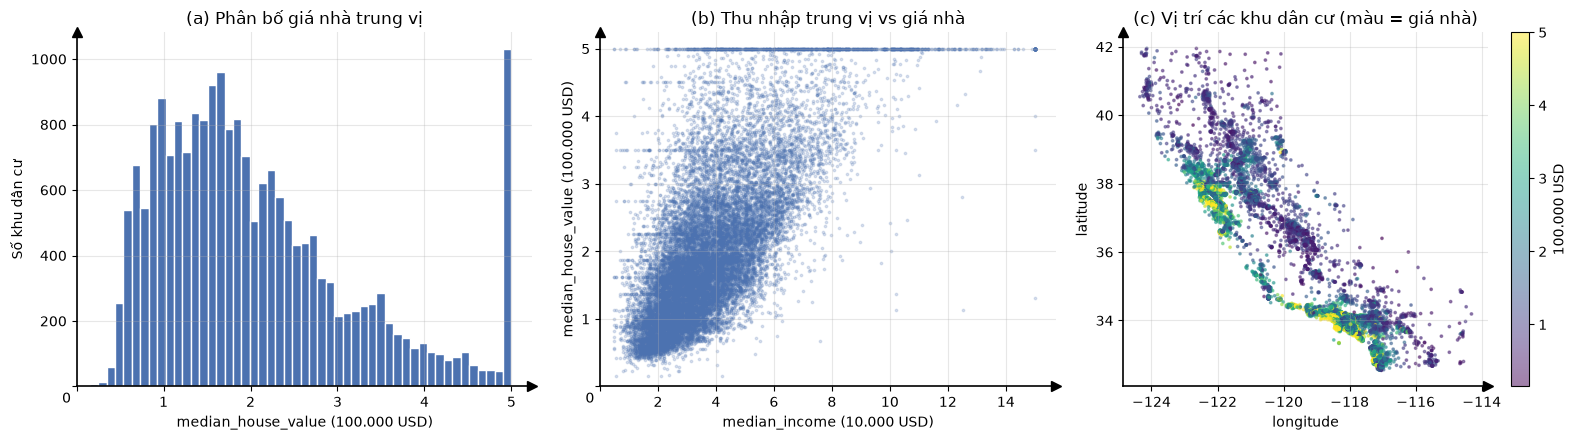

Hệ số tương quan Pearson với median_house_value:
  longitude           : -0.046
  latitude            : -0.144
  housing_median_age  : +0.106
  total_rooms         : +0.134
  total_bedrooms      : +0.050
  population          : -0.025
  households          : +0.066
  median_income       : +0.688

Số khu có giá = 500.001 USD (bị chặn trên): 965


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

# (a) Phân bố giá nhà
axes[0].hist(y_all / 1e5, bins=50, color="#4C72B0", edgecolor="white")
axes[0].set_title("(a) Phân bố giá nhà trung vị")
axes[0].set_xlabel("median_house_value (100.000 USD)")
axes[0].set_ylabel("Số khu dân cư")

# (b) Thu nhập vs giá nhà
axes[1].scatter(X_num[:, feature_names.index("median_income")], y_all / 1e5,
                s=3, alpha=0.2, color="#4C72B0")
axes[1].set_title("(b) Thu nhập trung vị vs giá nhà")
axes[1].set_xlabel("median_income (10.000 USD)")
axes[1].set_ylabel("median_house_value (100.000 USD)")

# (c) Vị trí địa lý, màu = giá nhà
sc = axes[2].scatter(X_num[:, 0], X_num[:, 1], c=y_all / 1e5, s=3,
                     cmap="viridis", alpha=0.5)
axes[2].set_title("(c) Vị trí các khu dân cư (màu = giá nhà)")
axes[2].set_xlabel("longitude")
axes[2].set_ylabel("latitude")
fig.colorbar(sc, ax=axes[2], label="100.000 USD")

oxy_axes(axes[0])
oxy_axes(axes[1])
# Bản đồ: điểm (0, 0) nằm ngoài California rất xa, nên không ép gốc 0
oxy_axes(axes[2], origin=False)
plt.tight_layout()
plt.show()

# Hệ số tương quan của từng đặc trưng với giá nhà (bỏ qua ô thiếu)
print("Hệ số tương quan Pearson với median_house_value:")
for j, name in enumerate(feature_names):
    ok = ~np.isnan(X_num[:, j])
    r = np.corrcoef(X_num[ok, j], y_all[ok])[0, 1]
    print(f"  {name:20s}: {r:+.3f}")
print("\nSố khu có giá = 500.001 USD (bị chặn trên):", int(np.sum(y_all >= 500001)))

**Nhận xét khám phá dữ liệu**

- `total_bedrooms` có **207 ô thiếu**, cần điền trước khi huấn luyện.
- Các đặc trưng có **thang đo rất khác nhau** (vd `median_income` khoảng 0,5–15, còn `total_rooms` lên tới hàng chục nghìn), nên cần chuẩn hóa để Gradient Descent hội tụ tốt.
- `median_income` tương quan mạnh nhất với giá nhà (hình b). Giá nhà cũng phụ thuộc rõ vào vị trí: nhà ven biển (Los Angeles, San Francisco) đắt hơn (hình c).
- Giá nhà bị **chặn trên ở 500.001 USD** (cột cao bất thường ở cuối hình a). Mô hình tuyến tính sẽ khó dự đoán đúng nhóm nhà đắt này.
- `ocean_proximity` là dữ liệu dạng chữ, cần chuyển sang số (one-hot). Nhóm `ISLAND` chỉ có 5 mẫu.

## 2. Tiền xử lý dữ liệu

Các bước:

1. **Chia dữ liệu** ngẫu nhiên: 70% train, 15% validation, 15% test. Tập val dùng để theo dõi quá trình học và chọn siêu tham số; tập test chỉ dùng một lần ở cuối.
2. **Điền giá trị thiếu** của `total_bedrooms` bằng **trung vị tính trên tập train**. Chỉ dùng tập train để tránh "nhìn trộm" thông tin của val/test.
3. **One-hot** cột `ocean_proximity` (bỏ nhóm `<1H OCEAN` làm nhóm tham chiếu, vì 5 cột one-hot luôn có tổng bằng 1 và sẽ trùng thông tin với bias $b$).
4. **Chuẩn hóa** (standardization) từng đặc trưng: $x' = \dfrac{x - \mu}{\sigma}$, với $\mu, \sigma$ tính trên tập train.
5. **Đổi đơn vị $y$** sang *100.000 USD* để loss có độ lớn dễ đọc.

In [6]:
n = len(y_all)
rng = np.random.default_rng(SEED)
perm = rng.permutation(n)

n_train = int(0.70 * n)
n_val = int(0.15 * n)
idx_train = perm[:n_train]
idx_val = perm[n_train:n_train + n_val]
idx_test = perm[n_train + n_val:]
print(f"train: {len(idx_train)}  |  val: {len(idx_val)}  |  test: {len(idx_test)}")

# (2) Điền giá trị thiếu bằng trung vị của tập train
train_median = np.nanmedian(X_num[idx_train], axis=0)
X_filled = np.where(np.isnan(X_num), train_median, X_num)
print("Còn giá trị thiếu:", int(np.isnan(X_filled).sum()))

# (3) One-hot cho ocean_proximity, bỏ nhóm tham chiếu '<1H OCEAN'
categories = [c for c in np.unique(ocean) if c != "<1H OCEAN"]
X_onehot = (ocean[:, None] == np.array(categories)[None, :]).astype(float)

X_all = np.hstack([X_filled, X_onehot])
all_feature_names = feature_names + [f"ocean_{c}" for c in categories]
print("Số đặc trưng d =", X_all.shape[1])
print(all_feature_names)

train: 14447  |  val: 3096  |  test: 3097
Còn giá trị thiếu: 0
Số đặc trưng d = 12
['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income', 'ocean_INLAND', 'ocean_ISLAND', 'ocean_NEAR BAY', 'ocean_NEAR OCEAN']


In [7]:
# (4) Chuẩn hóa bằng mean/std của tập train
mu = X_all[idx_train].mean(axis=0)
sigma = X_all[idx_train].std(axis=0)

def standardize(X):
    # Chuẩn hóa theo thống kê của tập train
    return (X - mu) / sigma

X_train, X_val, X_test = (standardize(X_all[i]) for i in (idx_train, idx_val, idx_test))

# (5) Đổi đơn vị y sang 100.000 USD
y_scaled = y_all / 1e5
y_train, y_val, y_test = y_scaled[idx_train], y_scaled[idx_val], y_scaled[idx_test]

print("X_train:", X_train.shape, " X_val:", X_val.shape, " X_test:", X_test.shape)
print("Mean các cột X_train (≈0):", np.round(X_train.mean(axis=0), 6).max())
print("Std các cột X_train (≈1):", np.round(X_train.std(axis=0), 6).min(), "-", np.round(X_train.std(axis=0), 6).max())

X_train: (14447, 12)  X_val: (3096, 12)  X_test: (3097, 12)
Mean các cột X_train (≈0): 0.0
Std các cột X_train (≈1): 1.0 - 1.0


## 3. Cài đặt mô hình Linear Regression từ đầu

Lớp `LinearRegressionGD` cài đặt đúng **Thuật toán 1 / 1b** ở Phần I:

| Bước | Công thức | Hàm |
|---|---|---|
| Initialize | $\mathbf{w} \leftarrow \mathbf{0}$, $b \leftarrow 0$ | `_initialize` |
| Tính $\hat y$ | $\hat{\mathbf{y}}_\mathcal{B} = \mathbf{X}_\mathcal{B}\mathbf{w} + b$ | `predict` |
| Tính Loss | $J_\mathcal{B} = \frac{1}{2m}\|\hat{\mathbf{y}}_\mathcal{B} - \mathbf{y}_\mathcal{B}\|^2 + \frac{\lambda}{2}\|\mathbf{w}\|^2$ | `compute_loss` |
| Tính Gradient | $\mathbf{g}_\mathbf{w} = \frac{1}{m}\mathbf{X}_\mathcal{B}^\top(\hat{\mathbf{y}}_\mathcal{B} - \mathbf{y}_\mathcal{B}) + \lambda\mathbf{w}$, $\;g_b = \frac{1}{m}\sum(\hat y - y)$ | `compute_gradients` |
| Update | $\mathbf{w} \leftarrow \mathbf{w} - \eta\mathbf{g}_\mathbf{w}$, $\;b \leftarrow b - \eta g_b$ | trong `fit` |

Với $\lambda = 0$ ta có Bài 1a; với $\lambda > 0$ ta có Bài 1b (thêm L2). Tham số `batch_size=None` nghĩa là dùng toàn bộ dữ liệu cho mỗi lần cập nhật (full-batch GD).

In [8]:
class LinearRegressionGD:
    # Linear Regression huấn luyện bằng mini-batch Gradient Descent (chỉ dùng NumPy)

    def __init__(self, learning_rate=0.01, batch_size=64, epochs=100,
                 lam=0.0, seed=0):
        self.learning_rate = learning_rate   # eta
        self.batch_size = batch_size         # m (None = full batch)
        self.epochs = epochs                 # số epoch E
        self.lam = lam                       # lambda của L2 (0 = không regularization)
        self.seed = seed
        self.w = None
        self.b = None
        self.history = {"train_loss": [], "val_loss": []}

    # Bước 1: Initialize
    def _initialize(self, n_features):
        self.w = np.zeros(n_features)
        self.b = 0.0

    # Bước 2: Tính y_hat = Xw + b
    def predict(self, X):
        return X @ self.w + self.b

    # Bước 3: Tính Loss = 1/(2m) * sum((y_hat - y)^2) + lambda/2 * ||w||^2
    def compute_loss(self, X, y):
        error = self.predict(X) - y
        data_loss = np.mean(error ** 2) / 2
        l2_penalty = self.lam / 2 * np.sum(self.w ** 2)
        return data_loss + l2_penalty

    # Bước 4: Tính Gradient
    def compute_gradients(self, X, y):
        m = X.shape[0]
        error = self.predict(X) - y                    # (y_hat - y), kích thước (m,)
        grad_w = X.T @ error / m + self.lam * self.w   # 1/m * X^T (y_hat - y) + lambda * w
        grad_b = np.mean(error)                        # 1/m * sum(y_hat - y)
        return grad_w, grad_b

    def fit(self, X, y, X_val=None, y_val=None, verbose_every=0):
        n_samples, n_features = X.shape
        m = n_samples if self.batch_size is None else self.batch_size
        rng = np.random.default_rng(self.seed)
        self._initialize(n_features)
        self.history = {"train_loss": [], "val_loss": []}

        for epoch in range(1, self.epochs + 1):
            # Xáo trộn dữ liệu đầu mỗi epoch
            order = rng.permutation(n_samples)
            for start in range(0, n_samples, m):
                batch = order[start:start + m]
                grad_w, grad_b = self.compute_gradients(X[batch], y[batch])
                # Bước 5: Update
                self.w -= self.learning_rate * grad_w
                self.b -= self.learning_rate * grad_b

            # Ghi lại loss sau mỗi epoch (tính trên toàn tập)
            with np.errstate(over="ignore", invalid="ignore"):
                train_loss = self.compute_loss(X, y)
                val_loss = self.compute_loss(X_val, y_val) if X_val is not None else np.nan
            self.history["train_loss"].append(train_loss)
            self.history["val_loss"].append(val_loss)

            # Dừng sớm nếu loss bùng nổ (learning rate quá lớn)
            if not np.isfinite(train_loss) or train_loss > 1e10:
                print(f"  [!] Loss phân kỳ ở epoch {epoch} (eta={self.learning_rate}) -> dừng.")
                break
            if verbose_every and epoch % verbose_every == 0:
                print(f"  epoch {epoch:4d} | train loss = {train_loss:.5f} | val loss = {val_loss:.5f}")
        return self

## 4. Kiểm tra tính đúng của code

Trước khi dùng dữ liệu thật, ta kiểm tra code theo 3 cách:

1. **Gradient check:** so gradient tính theo công thức với gradient xấp xỉ bằng sai phân $\dfrac{J(w_j + \varepsilon) - J(w_j - \varepsilon)}{2\varepsilon}$. Nếu công thức đạo hàm đúng thì hai giá trị gần như trùng nhau.
2. **Dữ liệu giả lập:** tự sinh dữ liệu từ $y = \mathbf{w}_\text{true}^\top\mathbf{x} + b_\text{true} + \text{nhiễu}$, rồi kiểm tra mô hình học lại được $\mathbf{w}_\text{true}, b_\text{true}$.
3. *(Ngoài bài giảng)* **So với nghiệm đóng** của bình phương tối thiểu (tính bằng `np.linalg.lstsq`). Khi $\lambda = 0$ và huấn luyện đủ lâu, GD phải hội tụ về đúng nghiệm này.

In [9]:
# (1) Gradient check trên dữ liệu ngẫu nhiên nhỏ, có cả L2
rng_check = np.random.default_rng(0)
Xc = rng_check.normal(size=(20, 5))
yc = rng_check.normal(size=20)

model_check = LinearRegressionGD(lam=0.3)
model_check.w = rng_check.normal(size=5)
model_check.b = 0.7

grad_w, grad_b = model_check.compute_gradients(Xc, yc)

eps = 1e-6
num_grad_w = np.zeros(5)
for j in range(5):
    old = model_check.w[j]
    model_check.w[j] = old + eps
    loss_plus = model_check.compute_loss(Xc, yc)
    model_check.w[j] = old - eps
    loss_minus = model_check.compute_loss(Xc, yc)
    model_check.w[j] = old
    num_grad_w[j] = (loss_plus - loss_minus) / (2 * eps)

old_b = model_check.b
model_check.b = old_b + eps; lp = model_check.compute_loss(Xc, yc)
model_check.b = old_b - eps; lm = model_check.compute_loss(Xc, yc)
model_check.b = old_b
num_grad_b = (lp - lm) / (2 * eps)

print("Gradient theo công thức :", np.round(grad_w, 6), round(grad_b, 6))
print("Gradient xấp xỉ số      :", np.round(num_grad_w, 6), round(num_grad_b, 6))
max_diff = max(np.max(np.abs(grad_w - num_grad_w)), abs(grad_b - num_grad_b))
print("Sai lệch lớn nhất:", max_diff)
assert max_diff < 1e-6, "Gradient sai!"
print("=> Gradient check: ĐẠT")

Gradient theo công thức : [ 0.377215  0.895468  0.236696 -1.210429 -0.539742] 0.826222
Gradient xấp xỉ số      : [ 0.377215  0.895468  0.236696 -1.210429 -0.539742] 0.826222
Sai lệch lớn nhất: 1.9365531400694636e-10
=> Gradient check: ĐẠT


In [10]:
# (2) Dữ liệu giả lập với tham số thật đã biết
rng_syn = np.random.default_rng(1)
w_true = np.array([2.0, -3.0, 0.5])
b_true = 4.0
X_syn = rng_syn.normal(size=(2000, 3))
y_syn = X_syn @ w_true + b_true + rng_syn.normal(scale=0.1, size=2000)

model_syn = LinearRegressionGD(learning_rate=0.05, batch_size=32, epochs=50)
model_syn.fit(X_syn, y_syn)

print("w thật:", w_true, "  b thật:", b_true)
print("w học :", np.round(model_syn.w, 3), "  b học :", round(model_syn.b, 3))
assert np.allclose(model_syn.w, w_true, atol=0.02) and abs(model_syn.b - b_true) < 0.02
print("=> Học lại đúng tham số: ĐẠT")

w thật: [ 2.  -3.   0.5]   b thật: 4.0
w học : [ 2.    -3.004  0.495]   b học : 3.997
=> Học lại đúng tham số: ĐẠT


## 5. Huấn luyện mô hình chính

Siêu tham số: $\eta = 0{,}01$, $m = 64$, $E = 100$ epoch, $\lambda = 0$ (chưa regularization). Mục 7 sẽ giải thích vì sao chọn $\eta = 0{,}01$.

In [11]:
start = time.time()
model = LinearRegressionGD(learning_rate=0.01, batch_size=64, epochs=100, lam=0.0, seed=SEED)
model.fit(X_train, y_train, X_val, y_val, verbose_every=20)
print(f"Thời gian huấn luyện: {time.time() - start:.1f} giây")

  epoch   20 | train loss = 0.23821 | val loss = 0.23128


  epoch   40 | train loss = 0.23767 | val loss = 0.23036


  epoch   60 | train loss = 0.23755 | val loss = 0.23063


  epoch   80 | train loss = 0.23770 | val loss = 0.23050


  epoch  100 | train loss = 0.23746 | val loss = 0.23061
Thời gian huấn luyện: 0.4 giây


In [12]:
# (3) So với nghiệm đóng của bình phương tối thiểu (ngoài bài giảng, chỉ để kiểm tra)
A = np.hstack([X_train, np.ones((len(X_train), 1))])        # thêm cột 1 cho bias
theta_closed, *_ = np.linalg.lstsq(A, y_train, rcond=None)
w_closed, b_closed = theta_closed[:-1], theta_closed[-1]

loss_closed = np.mean((A @ theta_closed - y_train) ** 2) / 2
print(f"Train loss của GD       : {model.compute_loss(X_train, y_train):.5f}")
print(f"Train loss nghiệm đóng  : {loss_closed:.5f}")
print("Chênh lệch lớn nhất giữa các trọng số:", np.round(np.max(np.abs(model.w - w_closed)), 4))

Train loss của GD       : 0.23746
Train loss nghiệm đóng  : 0.23745
Chênh lệch lớn nhất giữa các trọng số: 0.0038


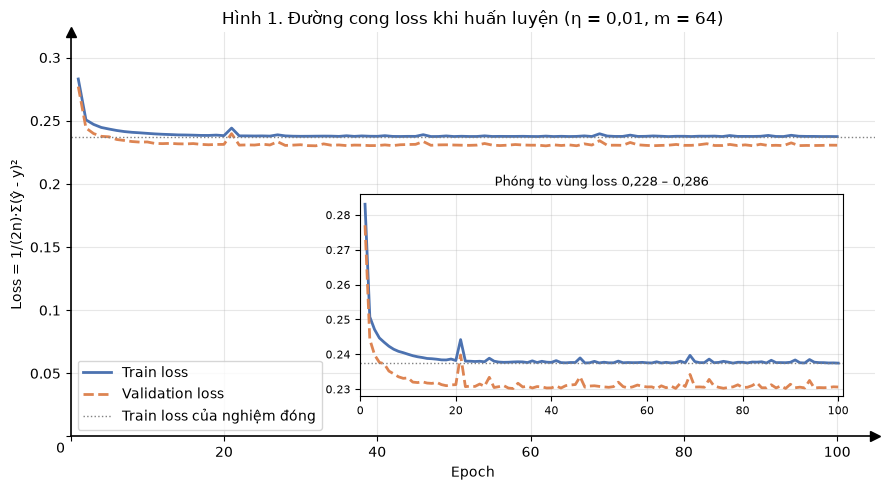

In [13]:
epochs_axis = np.arange(1, len(model.history["train_loss"]) + 1)
fig, ax = plt.subplots(figsize=(9, 5))

# Trục tung bắt đầu từ 0 nên các đường loss (0,23–0,28) nằm sát nhau ở phía trên.
# Khung phóng to (inset) ở dưới giúp nhìn rõ chi tiết.
axins = ax.inset_axes([0.36, 0.1, 0.6, 0.5])
for a in (ax, axins):
    a.plot(epochs_axis, model.history["train_loss"], label="Train loss", color="#4C72B0", lw=2)
    a.plot(epochs_axis, model.history["val_loss"], label="Validation loss", color="#DD8452", lw=2, ls="--")
    a.axhline(loss_closed, color="gray", lw=1, ls=":", label="Train loss của nghiệm đóng")
ax.set_ylim(0, 0.32)
axins.set_xlim(0, len(epochs_axis) + 1)
axins.set_ylim(0.228, 0.286)
axins.set_title("Phóng to vùng loss 0,228 – 0,286", fontsize=9)
axins.tick_params(labelsize=8)

ax.set_xlabel("Epoch")
ax.set_ylabel("Loss = 1/(2n)·Σ(ŷ - y)²")
ax.set_title("Hình 1. Đường cong loss khi huấn luyện (η = 0,01, m = 64)")
ax.legend(loc="lower left")
oxy_axes(ax)
plt.tight_layout()
plt.show()

**Đánh giá bằng các độ đo** (tự cài bằng NumPy):

- $\text{MSE} = \frac{1}{n}\sum(\hat y - y)^2$ (lưu ý: loss của mô hình $= \frac{1}{2}\text{MSE}$).
- $\text{RMSE} = \sqrt{\text{MSE}}$: sai số trung bình, cùng đơn vị với $y$.
- $\text{MAE} = \frac{1}{n}\sum|\hat y - y|$.
- *(Ngoài bài giảng)* $R^2 = 1 - \dfrac{\sum(\hat y - y)^2}{\sum(y - \bar y)^2}$: tỉ lệ phương sai của $y$ mà mô hình giải thích được ($R^2 = 1$ là hoàn hảo; $R^2 = 0$ tương đương luôn đoán giá trị trung bình).

In [14]:
def regression_metrics(y_true, y_pred):
    # Tính MSE, RMSE, MAE, R^2 bằng NumPy
    err = y_pred - y_true
    mse = np.mean(err ** 2)
    rmse = np.sqrt(mse)
    mae = np.mean(np.abs(err))
    r2 = 1 - np.sum(err ** 2) / np.sum((y_true - y_true.mean()) ** 2)
    return {"MSE": mse, "RMSE": rmse, "MAE": mae, "R2": r2}

# Mô hình cơ sở: luôn đoán giá trung bình của tập train (để so sánh)
baseline_pred = np.full_like(y_test, y_train.mean())

print(f"{'Tập':<22s}{'MSE':>8s}{'RMSE':>8s}{'MAE':>8s}{'R²':>8s}{'RMSE (USD)':>14s}")
results = {}
for name, Xs, ys in [("Train", X_train, y_train), ("Validation", X_val, y_val), ("Test", X_test, y_test)]:
    r = regression_metrics(ys, model.predict(Xs))
    results[name] = r
    print(f"{name:<22s}{r['MSE']:8.4f}{r['RMSE']:8.4f}{r['MAE']:8.4f}{r['R2']:8.4f}{r['RMSE']*1e5:14,.0f}")
rb = regression_metrics(y_test, baseline_pred)
print(f"{'Test – đoán trung bình':<22s}{rb['MSE']:8.4f}{rb['RMSE']:8.4f}{rb['MAE']:8.4f}{rb['R2']:8.4f}{rb['RMSE']*1e5:14,.0f}")

Tập                        MSE    RMSE     MAE      R²    RMSE (USD)
Train                   0.4749  0.6891  0.5001  0.6442        68,915
Validation              0.4612  0.6791  0.4960  0.6511        67,913
Test                    0.4712  0.6864  0.4983  0.6445        68,642
Test – đoán trung bình  1.3263  1.1517  0.9098 -0.0007       115,167


## 6. Vẽ và phân tích kết quả dự đoán

Hình 2 gồm hai biểu đồ trên tập test:

- **(a) Giá dự đoán $\hat y$ theo giá thật $y$.** Hai trục cùng thang đo, nên điểm nằm đúng trên đường $\hat y = y$ là dự đoán hoàn hảo. Điểm nằm trên đường là dự đoán cao hơn giá thật, điểm nằm dưới là dự đoán thấp hơn.
- **(b) Phần dư $e = \hat y - y$ theo giá dự đoán $\hat y$** *(residual plot)*. Ở notebook này phần dư lấy theo dấu $\hat y - y$ cho khớp biến `error` trong code; nhiều sách thống kê dùng $y - \hat y$, khi đó hình chỉ lật ngược lên xuống. Nếu mô hình tuyến tính phù hợp, các điểm phải nằm thành một dải **nằm ngang, đều hai phía quanh 0**, không có hình dạng gì đặc biệt. Đường xanh lá là **phần dư trung bình theo từng khoảng $\hat y$**, dùng để nhìn xu hướng dễ hơn.

**Vì sao trục hoành của (b) là $\hat y$ chứ không phải $y$?** Nếu vẽ phần dư theo giá thật $y$, ta **luôn** thấy một xu hướng dốc xuống với mọi mô hình có $R^2 < 1$, kể cả khi dữ liệu tuyến tính hoàn toàn. Lý do là với nghiệm bình phương tối thiểu ta có $\text{corr}(\hat y - y,\ y) = -\sqrt{1 - R^2}$ (đúng tuyệt đối trên tập train, xấp xỉ trên tập test). Như vậy xu hướng đó chỉ do cách vẽ tạo ra, không cho biết mô hình sai ở đâu. Còn phần dư và $\hat y$ thì **không tương quan tuyến tính** (điều kiện của nghiệm tối ưu, trên tập test thì xấp xỉ 0), nên nếu hình (b) vẫn có dạng cong hoặc loe rộng dần thì đó mới là dấu hiệu thật cho thấy mô hình có vấn đề.

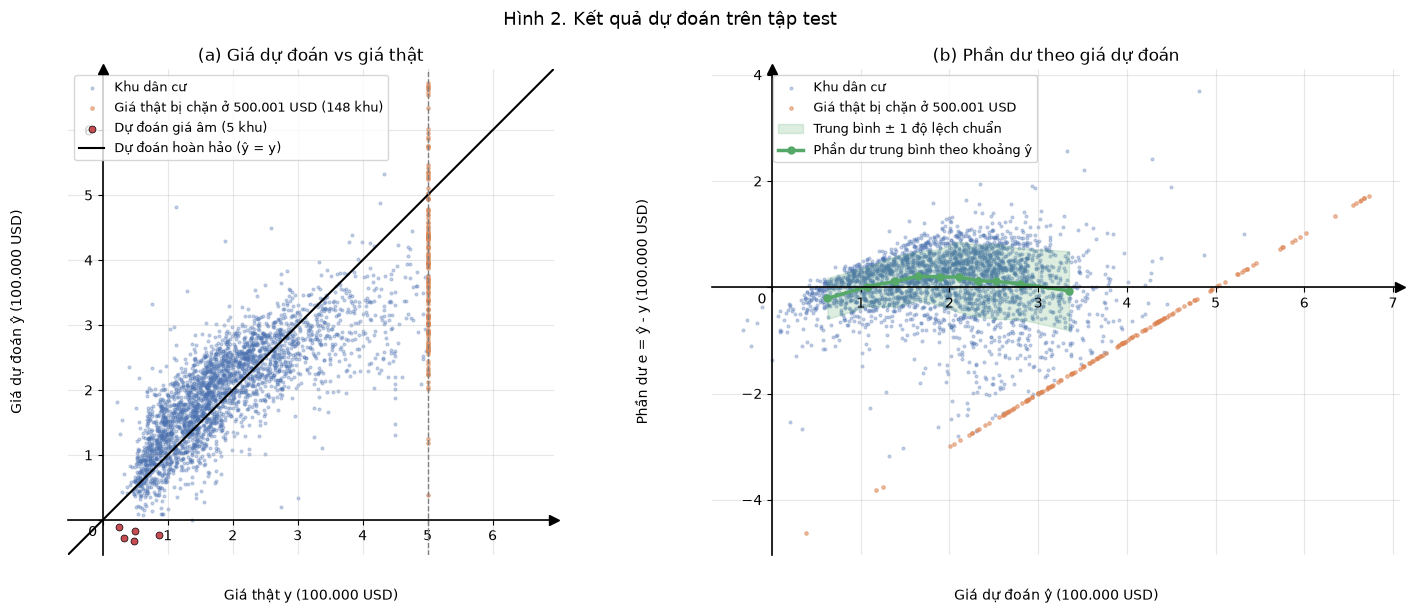

Số dự đoán âm (vô lý với giá nhà): 5
Phần dư trung bình với nhà giá bị chặn 500.001 USD: -1.093 (x100.000 USD)
Phần dư trung bình với các nhà còn lại            : +0.074 (x100.000 USD)

corr(phần dư, y)  = -0.604   (lý thuyết ≈ -sqrt(1 - R²) = -0.596)
corr(phần dư, ŷ)  = -0.009   (lý thuyết ≈ 0)

Phần dư theo từng khoảng ŷ (bỏ các khu bị chặn giá):
        Khoảng ŷ  Số khu  TB phần dư  Độ lệch chuẩn
  -0.32 –  0.91     295      -0.211          0.387
   0.91 –  1.24     295      +0.013          0.370
   1.24 –  1.52     295      +0.111          0.473
   1.52 –  1.76     295      +0.207          0.460
   1.76 –  2.00     294      +0.195          0.528
   2.00 –  2.21     295      +0.195          0.667
   2.21 –  2.43     295      +0.124          0.676
   2.43 –  2.64     295      +0.109          0.708
   2.64 –  2.96     295      +0.065          0.668
   2.96 –  5.32     295      -0.065          0.747


In [15]:
y_pred_test = model.predict(X_test)
residual = y_pred_test - y_test              # phần dư e = ŷ - y

capped = y_test >= 5.00001 - 1e-9            # nhà có giá bị chặn ở 500.001 USD
negative = y_pred_test < 0                   # dự đoán giá âm (vô lý)
normal = ~capped & ~negative                 # các điểm còn lại

# Màu dùng chung cho hai hình
C_NORMAL, C_CAPPED, C_NEG, C_TREND = "#4C72B0", "#DD8452", "#C44E52", "#55A868"

fig, axes = plt.subplots(1, 2, figsize=(15, 6.2))

# ---------- (a) Giá dự đoán vs giá thật ----------
ax = axes[0]
ax.scatter(y_test[normal], y_pred_test[normal], s=4, alpha=0.3, color=C_NORMAL,
           label="Khu dân cư")
ax.scatter(y_test[capped], y_pred_test[capped], s=6, alpha=0.5, color=C_CAPPED,
           label=f"Giá thật bị chặn ở 500.001 USD ({capped.sum()} khu)")
ax.scatter(y_test[negative], y_pred_test[negative], s=25, color=C_NEG,
           edgecolor="black", lw=0.5, zorder=3,
           label=f"Dự đoán giá âm ({negative.sum()} khu)")

# Hai trục dùng CHUNG một khoảng giá trị và cùng tỉ lệ -> đường ŷ = y nghiêng đúng 45°
lo = min(y_test.min(), y_pred_test.min())
hi = max(y_test.max(), y_pred_test.max())
pad = 0.03 * (hi - lo)
lims = (lo - pad, hi + pad)
ax.plot(lims, lims, color="black", lw=1.5, label="Dự đoán hoàn hảo (ŷ = y)")
ax.axvline(5.00001, color="gray", lw=1, ls="--")
ax.set_xlim(lims)
ax.set_ylim(lims)
ax.set_aspect("equal")
ax.set_xlabel("Giá thật y (100.000 USD)")
ax.set_ylabel("Giá dự đoán ŷ (100.000 USD)")
ax.set_title("(a) Giá dự đoán vs giá thật")
ax.legend(loc="upper left", fontsize=9)

# ---------- (b) Phần dư theo giá dự đoán ----------
ax = axes[1]
ax.scatter(y_pred_test[~capped], residual[~capped], s=4, alpha=0.3, color=C_NORMAL,
           label="Khu dân cư")
ax.scatter(y_pred_test[capped], residual[capped], s=6, alpha=0.5, color=C_CAPPED,
           label="Giá thật bị chặn ở 500.001 USD")

# Chia ŷ (của các khu không bị chặn giá) thành 10 khoảng có số điểm bằng nhau,
# tính trung bình và độ lệch chuẩn của phần dư trong từng khoảng
n_bins = 10
yp_ok, res_ok = y_pred_test[~capped], residual[~capped]
edges = np.quantile(yp_ok, np.linspace(0, 1, n_bins + 1))
bin_id = np.clip(np.digitize(yp_ok, edges[1:-1]), 0, n_bins - 1)
bin_center = np.array([yp_ok[bin_id == k].mean() for k in range(n_bins)])
bin_mean = np.array([res_ok[bin_id == k].mean() for k in range(n_bins)])
bin_std = np.array([res_ok[bin_id == k].std() for k in range(n_bins)])

ax.fill_between(bin_center, bin_mean - bin_std, bin_mean + bin_std,
                color=C_TREND, alpha=0.2, label="Trung bình ± 1 độ lệch chuẩn")
ax.plot(bin_center, bin_mean, "o-", color=C_TREND, lw=2.5, ms=5,
        label="Phần dư trung bình theo khoảng ŷ")
ax.set_xlabel("Giá dự đoán ŷ (100.000 USD)")
ax.set_ylabel("Phần dư e = ŷ - y (100.000 USD)")
ax.set_title("(b) Phần dư theo giá dự đoán")
ax.legend(loc="upper left", bbox_to_anchor=(0.08, 1.0), fontsize=9)

fig.suptitle("Hình 2. Kết quả dự đoán trên tập test", fontsize=13)
oxy_axes(axes[0])
oxy_axes(axes[1])   # trục hoành (e = 0) chính là đường phần dư bằng 0
plt.tight_layout()
plt.show()

# ---------- Các con số dùng cho phần phân tích ----------
print("Số dự đoán âm (vô lý với giá nhà):", int(negative.sum()))
print(f"Phần dư trung bình với nhà giá bị chặn 500.001 USD: {residual[capped].mean():+.3f} (x100.000 USD)")
print(f"Phần dư trung bình với các nhà còn lại            : {residual[~capped].mean():+.3f} (x100.000 USD)")

# Vì sao không vẽ phần dư theo y: tương quan với y luôn âm, với ŷ thì ≈ 0
r2_test = results["Test"]["R2"]
print(f"\ncorr(phần dư, y)  = {np.corrcoef(residual, y_test)[0, 1]:+.3f}"
      f"   (lý thuyết ≈ -sqrt(1 - R²) = {-np.sqrt(1 - r2_test):+.3f})")
print(f"corr(phần dư, ŷ)  = {np.corrcoef(residual, y_pred_test)[0, 1]:+.3f}   (lý thuyết ≈ 0)")

print("\nPhần dư theo từng khoảng ŷ (bỏ các khu bị chặn giá):")
print(f"{'Khoảng ŷ':>16s}{'Số khu':>8s}{'TB phần dư':>12s}{'Độ lệch chuẩn':>15s}")
for k in range(n_bins):
    print(f"{edges[k]:7.2f} – {edges[k + 1]:5.2f}{np.sum(bin_id == k):8d}"
          f"{bin_mean[k]:+12.3f}{bin_std[k]:15.3f}")

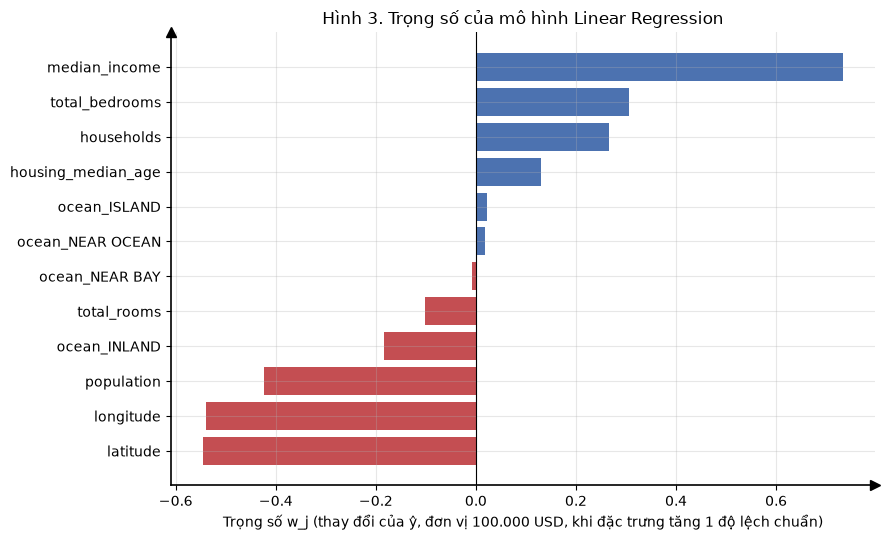

bias b = 2.0752  (≈ giá trung bình của tập train = 2.0759)


In [16]:
# Trọng số của mô hình (đặc trưng đã chuẩn hóa nên có thể so sánh độ lớn)
order = np.argsort(model.w)
colors = ["#C44E52" if v < 0 else "#4C72B0" for v in model.w[order]]

fig, ax = plt.subplots(figsize=(9, 5.5))
ax.barh(np.array(all_feature_names)[order], model.w[order], color=colors)
ax.axvline(0, color="black", lw=0.8)
ax.set_xlabel("Trọng số w_j (thay đổi của ŷ, đơn vị 100.000 USD, khi đặc trưng tăng 1 độ lệch chuẩn)")
ax.set_title("Hình 3. Trọng số của mô hình Linear Regression")
# Trục tung là tên đặc trưng (không có số 0), nên chỉ vẽ trục vuông góc ở góc dưới-trái;
# đường đen đứng là mốc w = 0
oxy_axes(ax, origin=False)
plt.tight_layout()
plt.show()

print(f"bias b = {model.b:.4f}  (≈ giá trung bình của tập train = {y_train.mean():.4f})")

**Phân tích kết quả (mô hình chính, $\lambda = 0$)**

1. **Quá trình hội tụ (Hình 1):** loss giảm rất nhanh trong vài epoch đầu, sau đó giảm chậm dần và gần như nằm ngang (các gai nhỏ là do nhiễu của mini-batch). Train loss của GD gần như trùng với nghiệm đóng, và các trọng số khớp nghiệm đóng tới khoảng 2 chữ số thập phân, tức GD đã hội tụ về đúng cực tiểu. Val loss luôn xấp xỉ train loss (thậm chí hơi thấp hơn, do cách chia ngẫu nhiên), **không có dấu hiệu overfitting**: mô hình chỉ có 12 trọng số + 1 bias (13 tham số), trong khi có hơn 14.000 mẫu huấn luyện.
2. **Độ chính xác:** $R^2 \approx 0{,}64$–$0{,}65$ trên cả train, val và test. RMSE khoảng **68–69 nghìn USD**, tốt hơn nhiều so với cách luôn đoán giá trung bình (RMSE khoảng 115 nghìn USD, $R^2 \approx 0$). Kết quả train/val/test gần nhau cho thấy mô hình tổng quát hóa ổn định.
3. **Mô hình vẫn còn hạn chế (hơi underfitting, Hình 2):**
    - **Hình 2a:** các điểm tản rộng quanh đường $\hat y = y$. Nhóm nhà **bị chặn giá ở 500.001 USD** (148 khu, màu cam) tạo thành một cột dọc tại $y = 5$: giá thật của chúng có thể cao hơn nhiều nhưng bị ghi là 500.001 USD, nên dự đoán cho nhóm này trải rất rộng, từ khoảng 0,4 đến 6,7 (trung vị ≈ 3,9). Trung bình mô hình dự đoán **thấp hơn** giá ghi nhận khoảng 109 nghìn USD.
    - **Hình 2b cho thấy quan hệ không hoàn toàn tuyến tính.** Phần dư và $\hat y$ gần như không tương quan (−0,01), đúng như lý thuyết. Nhưng đường trung bình (xanh lá) lại **cong hình ∩**: phần dư trung bình là −0,21 ở nhóm $\hat y$ thấp nhất, tăng lên khoảng +0,20 khi $\hat y \approx 1{,}5$–$2{,}2$, rồi giảm xuống −0,07 ở nhóm $\hat y$ cao nhất. Tức là mô hình đoán **thấp** với nhà rẻ, **cao** với nhà giá trung bình và lại **thấp** với nhà đắt. Sai số có quy luật như vậy nghĩa là mô hình tuyến tính **bias cao**: giá nhà tăng nhanh dần theo các đặc trưng (quan hệ cong), còn đường thẳng không mô tả được. Ở nhóm $\hat y$ thấp còn có thêm một nguyên nhân: giá thật không thể nhỏ hơn khoảng 15.000 USD, nên khi $\hat y$ rất thấp hoặc âm thì chắc chắn $y > \hat y$.
    - **Phương sai sai số không đều** (heteroscedasticity): độ lệch chuẩn của phần dư tăng từ khoảng 0,37–0,39 ($\hat y < 1{,}24$) lên khoảng 0,75 ($\hat y > 2{,}96$), thấy rõ ở dải xanh lá loe rộng dần. Nhà càng đắt thì dự đoán càng kém chắc chắn.
    - Các khu bị chặn giá tạo thành **một đường chéo riêng** $e = \hat y - 5$ ở Hình 2b (màu cam), nằm hẳn dưới dải chính: đây là sai số do dữ liệu bị cắt, không phải nhiễu ngẫu nhiên.
    - Có 5 khu trong tập test được dự đoán **giá âm** (điểm đỏ ở Hình 2a), điều vô lý mà mô hình tuyến tính không tự ngăn được.
    - *Lưu ý:* nếu vẽ phần dư theo giá thật $y$ thì sẽ thấy xu hướng dốc xuống rất rõ (tương quan −0,60). Tuy nhiên đó chỉ là hệ quả toán học của $R^2 < 1$ (xem giải thích ở đầu mục 6), không phải bằng chứng cho thấy quan hệ phi tuyến.
4. **Ý nghĩa các trọng số (Hình 3):** vì đặc trưng đã được chuẩn hóa, độ lớn $|w_j|$ phản ánh mức ảnh hưởng.
    - `median_income` có trọng số dương lớn nhất: thu nhập cao thì giá nhà cao, khớp với hệ số tương quan +0,69 ở mục 1.
    - `longitude` và `latitude` đều âm và lớn: khi các yếu tố khác giữ nguyên, càng lên phía bắc hoặc sang phía đông (vào sâu trong đất liền) thì giá càng giảm. `ocean_INLAND` âm: nhà trong đất liền rẻ hơn nhóm tham chiếu `<1H OCEAN`.
    - `total_rooms`, `total_bedrooms`, `population`, `households` **tương quan rất mạnh với nhau** (đa cộng tuyến, vì cùng tăng theo quy mô khu dân cư). Vì vậy trọng số riêng lẻ của chúng có dấu khác nhau và khó diễn giải trực tiếp (vd `total_rooms` âm nhưng `total_bedrooms` dương); mô hình dùng chúng kết hợp với nhau. Ví dụ `population` âm: khi giữ nguyên số hộ, dân số lớn hơn nghĩa là mỗi hộ đông người hơn, thường gắn với khu giá thấp hơn.

## 7. Thí nghiệm: ảnh hưởng của learning rate $\eta$ và batch size $m$

### 7.1. Learning rate $\eta$

Giữ $m = 64$, huấn luyện 30 epoch với $\eta \in \{0{,}001;\ 0{,}01;\ 0{,}03;\ 0{,}05\}$.

eta = 0.001 : train loss cuối = 0.24676  (số epoch chạy: 30)


eta = 0.01  : train loss cuối = 0.23769  (số epoch chạy: 30)


eta = 0.03  : train loss cuối = 0.23907  (số epoch chạy: 30)
  [!] Loss phân kỳ ở epoch 7 (eta=0.05) -> dừng.
eta = 0.05  : train loss cuối = 3.9678e+11  (số epoch chạy: 7)


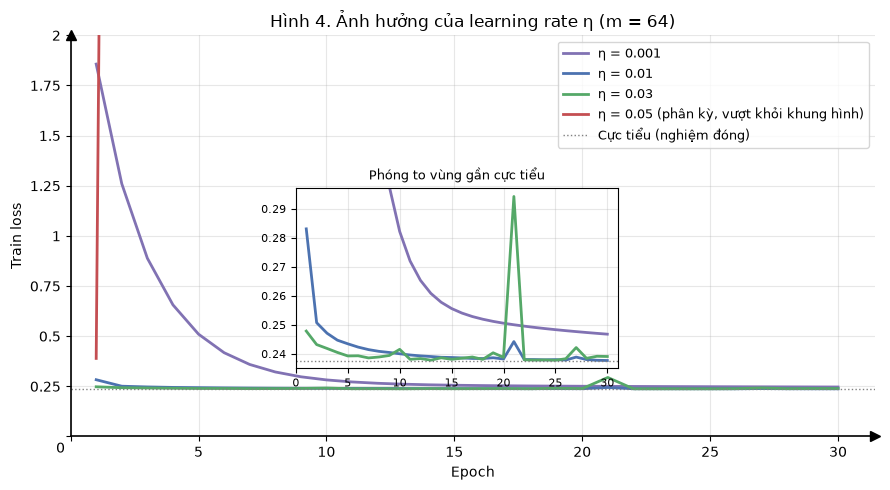

In [17]:
lr_list = [0.001, 0.01, 0.03, 0.05]
lr_hist = {}
for lr in lr_list:
    m_lr = LinearRegressionGD(learning_rate=lr, batch_size=64, epochs=30, seed=SEED)
    m_lr.fit(X_train, y_train, X_val, y_val)
    lr_hist[lr] = m_lr.history["train_loss"]
    last = m_lr.history["train_loss"][-1]
    print(f"eta = {lr:<6}: train loss cuối = {last:.5g}  (số epoch chạy: {len(m_lr.history['train_loss'])})")

fig, ax = plt.subplots(figsize=(9, 5))

# Thang log không có số 0, nên dùng thang thường bắt đầu từ 0 + khung phóng to vùng cực tiểu
axins = ax.inset_axes([0.28, 0.17, 0.4, 0.45])
colors_lr = ["#8172B3", "#4C72B0", "#55A868", "#C44E52"]
for lr, c in zip(lr_list, colors_lr):
    h = np.array(lr_hist[lr])
    label = f"η = {lr}"
    if len(h) < 30:
        label += " (phân kỳ, vượt khỏi khung hình)"
    for a in (ax, axins):
        a.plot(np.arange(1, len(h) + 1), h, label=label, color=c, lw=2)
for a in (ax, axins):
    a.axhline(loss_closed, color="gray", lw=1, ls=":", label="Cực tiểu (nghiệm đóng)")
ax.set_ylim(0, 2.0)
axins.set_xlim(0, 31)
# Giới hạn trên: điểm cao nhất (từ epoch 2) của hai đường η = 0,01 và 0,03
zoom_top = max(np.max(lr_hist[lr][1:]) for lr in (0.01, 0.03)) + 0.003
axins.set_ylim(0.235, zoom_top)
axins.set_title("Phóng to vùng gần cực tiểu", fontsize=9)
axins.tick_params(labelsize=8)

ax.set_xlabel("Epoch")
ax.set_ylabel("Train loss")
ax.set_title("Hình 4. Ảnh hưởng của learning rate η (m = 64)")
ax.legend(loc="upper right", fontsize=9)
oxy_axes(ax)
plt.tight_layout()
plt.show()

**Nhận xét learning rate**

- **$\eta = 0{,}001$ (quá nhỏ):** loss giảm đều nhưng **rất chậm**; sau 30 epoch vẫn còn cách xa cực tiểu.
- **$\eta = 0{,}01$ và $0{,}03$ (phù hợp):** hội tụ về gần cực tiểu chỉ sau 1–2 epoch. Với $\eta = 0{,}03$ mỗi bước dài hơn nên bị nhiễu của mini-batch làm dao động nhiều hơn quanh cực tiểu (vd. gai nhọn ở epoch 21); loss cuối của nó hơi cao hơn so với $\eta = 0{,}01$.
- **$\eta = 0{,}05$ (quá lớn):** mỗi bước nhảy quá xa, vượt qua điểm cực tiểu và bị đẩy ra xa hơn, nên **loss phân kỳ** (bùng nổ lên vô cùng). Ngưỡng này khá thấp vì một số đặc trưng tương quan rất mạnh (`total_rooms`, `total_bedrooms`, `population`, `households`), làm mặt loss rất "dốc" theo một số hướng.

→ Learning rate điều chỉnh tốc độ cập nhật (đúng như bài giảng): quá nhỏ thì học chậm, quá lớn thì không hội tụ. Vì vậy mô hình chính chọn $\eta = 0{,}01$ cho an toàn.

### 7.2. Batch size $m$

Giữ $\eta = 0{,}01$, huấn luyện 30 epoch với $m \in \{8,\ 32,\ 64,\ 512,\ n\}$ ($m = n$: full-batch GD, mỗi epoch chỉ cập nhật 1 lần).

  [!] Loss phân kỳ ở epoch 3 (eta=0.01) -> dừng.
m =         8:  1806 iterations/epoch | val loss cuối = PHÂN KỲ | thời gian = 0.07s


m =        32:   452 iterations/epoch | val loss cuối = 0.2313 | thời gian = 0.21s
m =        64:   226 iterations/epoch | val loss cuối = 0.2310 | thời gian = 0.11s
m =       512:    29 iterations/epoch | val loss cuối = 0.2382 | thời gian = 0.05s


m =  n (full):     1 iterations/epoch | val loss cuối = 1.6034 | thời gian = 0.03s


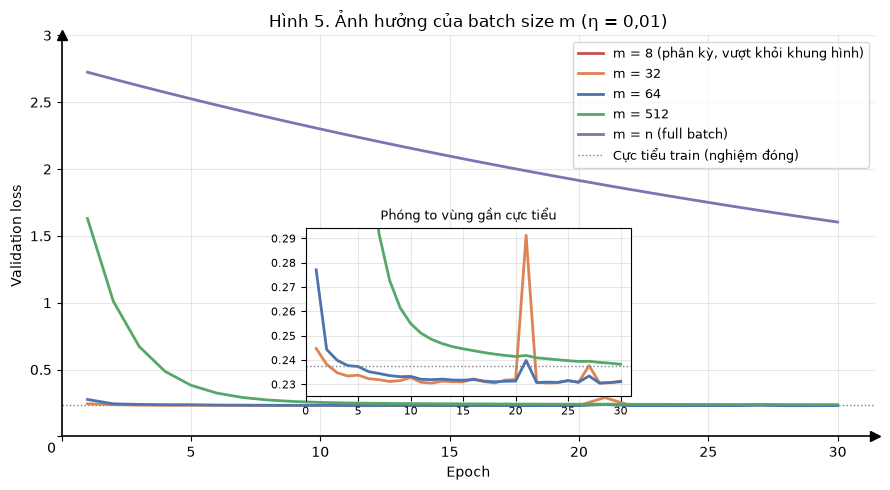

In [18]:
bs_list = [8, 32, 64, 512, None]
bs_hist, bs_time = {}, {}
for bs in bs_list:
    t0 = time.time()
    m_bs = LinearRegressionGD(learning_rate=0.01, batch_size=bs, epochs=30, seed=SEED)
    m_bs.fit(X_train, y_train, X_val, y_val)
    bs_time[bs] = time.time() - t0
    bs_hist[bs] = m_bs.history["val_loss"]
    n_iter = int(np.ceil(len(X_train) / (bs or len(X_train))))
    last = bs_hist[bs][-1]
    last_txt = f"{last:.4f}" if np.isfinite(last) and last < 1e10 else "PHÂN KỲ"
    print(f"m = {str(bs or 'n (full)'):>9}: {n_iter:5d} iterations/epoch | "
          f"val loss cuối = {last_txt} | thời gian = {bs_time[bs]:.2f}s")

fig, ax = plt.subplots(figsize=(9, 5))

# Thang log không có số 0, nên dùng thang thường bắt đầu từ 0 + khung phóng to vùng cực tiểu
axins = ax.inset_axes([0.3, 0.1, 0.4, 0.42])
for bs, c in zip(bs_list, ["#C44E52", "#DD8452", "#4C72B0", "#55A868", "#8172B3"]):
    h = np.array(bs_hist[bs])
    label = f"m = {bs or 'n (full batch)'}"
    if len(h) < 30:
        label += " (phân kỳ, vượt khỏi khung hình)"
    for a in (ax, axins):
        a.plot(np.arange(1, len(h) + 1), h, label=label, color=c, lw=2)
for a in (ax, axins):
    a.axhline(loss_closed, color="gray", lw=1, ls=":", label="Cực tiểu train (nghiệm đóng)")
ax.set_ylim(0, 3.0)
axins.set_xlim(0, 31)
zoom_top = max(np.max(bs_hist[bs][1:]) for bs in (32, 64)) + 0.003
axins.set_ylim(0.225, zoom_top)
axins.set_title("Phóng to vùng gần cực tiểu", fontsize=9)
axins.tick_params(labelsize=8)

ax.set_xlabel("Epoch")
ax.set_ylabel("Validation loss")
ax.set_title("Hình 5. Ảnh hưởng của batch size m (η = 0,01)")
ax.legend(loc="upper right", fontsize=9)
oxy_axes(ax)
plt.tight_layout()
plt.show()

**Nhận xét batch size**

- **$m = 8$ bị phân kỳ** ngay với $\eta = 0{,}01$, dù $\eta$ này chạy tốt với $m = 64$. Gradient ước lượng từ chỉ 8 mẫu rất nhiễu, có batch cho gradient rất lớn, nên với cùng $\eta$ bước cập nhật có thể quá xa. Batch càng nhỏ thì càng cần $\eta$ nhỏ hơn.
- **$m = 32$ và $m = 64$:** mỗi epoch có nhiều iteration (nhiều lần cập nhật), nên chỉ sau vài epoch đã về gần cực tiểu.
- **$m = 512$:** ổn định, ít nhiễu nhưng chỉ có khoảng 29 lần cập nhật mỗi epoch, nên giảm chậm hơn tính theo epoch.
- **Full batch** ($m = n$) chỉ cập nhật 30 lần trong 30 epoch, nên loss vẫn còn **rất cao**. Muốn hội tụ, full batch cần nhiều epoch hơn hẳn (hoặc $\eta$ lớn hơn).
- → $m = 64$ là lựa chọn cân bằng: đủ ổn định để không phân kỳ với $\eta = 0{,}01$, và đủ nhiều lần cập nhật mỗi epoch để hội tụ nhanh.

## 8. Thí nghiệm: ảnh hưởng của L2 regularization $\lambda$ (minh họa Bài 4)

Trên toàn bộ ~14.000 mẫu train, mô hình 13 tham số (12 trọng số + 1 bias) không bị overfitting (mục 5), nên L2 gần như không có tác dụng. Để thấy rõ ba trường hợp của Bài 4, ta cố ý tạo tình huống **ít dữ liệu**: chỉ lấy **30 mẫu train** (với 12 đặc trưng), đánh giá trên toàn bộ tập validation.

Thử $\lambda \in \{0;\ 0{,}001;\ 0{,}01;\ 0{,}03;\ 0{,}1;\ 0{,}3;\ 1;\ 3;\ 10\}$ (full-batch GD, $\eta = 0{,}05$, 3000 epoch để hội tụ). Luôn giữ $\eta\lambda < 1$ như điều kiện ở Bài 1b.

In [19]:
small_idx = np.random.default_rng(7).choice(len(X_train), size=30, replace=False)
X_small, y_small = X_train[small_idx], y_train[small_idx]

lam_list = [0, 0.001, 0.01, 0.03, 0.1, 0.3, 1, 3, 10]
lam_train, lam_val, lam_norm, lam_models = [], [], [], {}
for lam in lam_list:
    m_l2 = LinearRegressionGD(learning_rate=0.05, batch_size=None, epochs=3000, lam=lam, seed=SEED)
    m_l2.fit(X_small, y_small)
    lam_models[lam] = m_l2
    lam_train.append(regression_metrics(y_small, m_l2.predict(X_small))["MSE"])
    lam_val.append(regression_metrics(y_val, m_l2.predict(X_val))["MSE"])
    lam_norm.append(np.linalg.norm(m_l2.w))

print(f"{'lambda':>8s}{'Train MSE':>12s}{'Val MSE':>10s}{'||w||':>9s}")
for lam, a, b_, c in zip(lam_list, lam_train, lam_val, lam_norm):
    print(f"{lam:>8}{a:12.4f}{b_:10.4f}{c:9.3f}")
best_lam = lam_list[int(np.argmin(lam_val))]
print("\nλ cho val MSE nhỏ nhất:", best_lam)

  lambda   Train MSE   Val MSE    ||w||
       0      0.1709    0.6351    1.308
   0.001      0.1710    0.6325    1.285
    0.01      0.1730    0.6200    1.128
    0.03      0.1798    0.6186    0.951
     0.1      0.1992    0.6477    0.747
     0.3      0.2388    0.7268    0.579
       1      0.3420    0.8863    0.389
       3      0.5154    1.0539    0.223
      10      0.7222    1.2059    0.093

λ cho val MSE nhỏ nhất: 0.03


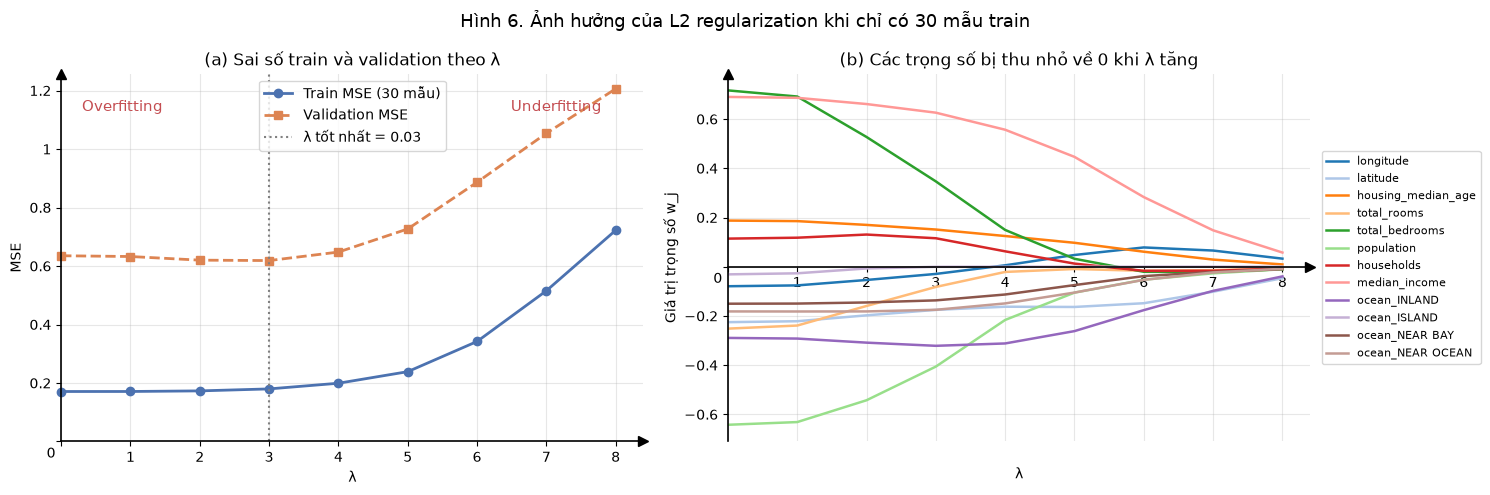

In [20]:
x_pos = np.arange(len(lam_list))
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# (a) Train/Val MSE theo lambda
axes[0].plot(x_pos, lam_train, "o-", color="#4C72B0", lw=2, label="Train MSE (30 mẫu)", clip_on=False)
axes[0].plot(x_pos, lam_val, "s--", color="#DD8452", lw=2, label="Validation MSE", clip_on=False)
axes[0].axvline(lam_list.index(best_lam), color="gray", ls=":", label=f"λ tốt nhất = {best_lam}")
axes[0].set_xticks(x_pos)
axes[0].set_xticklabels([str(l) for l in lam_list])
axes[0].set_xlabel("λ")
axes[0].set_ylabel("MSE")
axes[0].set_title("(a) Sai số train và validation theo λ")
axes[0].text(0.3, max(lam_val) * 0.97, "Overfitting", color="#C44E52", fontsize=11, va="top")
axes[0].text(len(lam_list) - 1.2, max(lam_val) * 0.97, "Underfitting", color="#C44E52", fontsize=11, va="top", ha="right")
axes[0].legend(loc="upper center")

# (b) Trọng số theo lambda
W_path = np.array([lam_models[l].w for l in lam_list])
cmap = plt.get_cmap("tab20")
for j in range(W_path.shape[1]):
    axes[1].plot(x_pos, W_path[:, j], lw=1.8, color=cmap(j), label=all_feature_names[j])
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels([str(l) for l in lam_list])
axes[1].set_xlabel("λ")
axes[1].set_ylabel("Giá trị trọng số w_j")
axes[1].set_title("(b) Các trọng số bị thu nhỏ về 0 khi λ tăng")
axes[1].legend(fontsize=8, loc="center left", bbox_to_anchor=(1.01, 0.5))
fig.suptitle("Hình 6. Ảnh hưởng của L2 regularization khi chỉ có 30 mẫu train", fontsize=13)
# Trục hoành là vị trí các giá trị λ: vị trí 0 ứng với λ = 0
oxy_axes(axes[0])
oxy_axes(axes[1])   # trục hoành chính là đường w = 0
plt.tight_layout()
plt.show()

**Nhận xét: khớp với 3 trường hợp của Bài 4** (số liệu ở bảng trên)

- **$\lambda = 0$:** train MSE **thấp nhất** (≈ 0,17) nhưng val MSE cao (≈ 0,64), gấp gần 4 lần → **overfitting** (variance cao). Chuẩn $\|\mathbf{w}\|$ **lớn nhất** (≈ 1,31): với chỉ 30 mẫu, mô hình dùng trọng số lớn để fit sát cả nhiễu. So với mô hình học trên đủ 14.447 mẫu (val MSE ≈ 0,46), val MSE ở đây kém hơn nhiều.
- **$\lambda$ vừa phải ($\lambda = 0{,}01$–$0{,}03$):** train MSE tăng nhẹ (≈ 0,18), còn **val MSE giảm xuống thấp nhất** (≈ 0,62, tại $\lambda = 0{,}03$). $\|\mathbf{w}\|$ giảm còn ≈ 0,95. Đây là điểm cân bằng bias–variance. Mức cải thiện vừa phải, vì mô hình tuyến tính 12 đặc trưng vốn không quá phức tạp.
- **$\lambda$ rất lớn ($\lambda = 3, 10$):** các trọng số bị ép gần 0 ($\|\mathbf{w}\| \approx 0{,}09$ khi $\lambda = 10$, Hình 6b), mô hình gần thành mô hình hằng số $\hat y \approx b$. Cả train MSE (≈ 0,72) và val MSE (≈ 1,21) đều **cao**, val MSE tiến gần mô hình đoán trung bình (≈ 1,33) → **underfitting** (bias cao).
- Hình 6b: nhìn chung các trọng số bị **kéo dần về 0** khi $\lambda$ tăng ($\|\mathbf{w}\|$ giảm đều theo bảng trên). Một vài trọng số có thể đổi dấu hoặc tạm tăng nhẹ vì các đặc trưng tương quan với nhau, nhưng khi $\lambda$ rất lớn thì tất cả đều gần 0. Không có trọng số nào bị ép về **đúng** 0 và nằm yên ở đó, đúng như bài giảng nêu về L2 ("thường không làm weight bằng chính xác 0").

## 9. Tổng kết

1. Đã cài đặt từ đầu Linear Regression bằng NumPy theo đúng khung **Initialize → Tính ŷ → Tính Loss → Tính Gradient → Update**, hỗ trợ mini-batch và L2. Code đã được kiểm tra bằng gradient check, bằng dữ liệu giả lập (học lại đúng $\mathbf{w}, b$), và bằng cách so với nghiệm đóng.
2. Trên California Housing, mô hình đạt $R^2 \approx 0{,}64$, RMSE khoảng 68,6 nghìn USD trên tập test, tốt hơn hẳn mô hình đoán trung bình. Train, val và test cho kết quả gần nhau, **không overfitting**.
3. Hạn chế: quan hệ giữa đặc trưng và giá nhà không hoàn toàn tuyến tính, và giá bị chặn ở 500.001 USD, nên phần dư theo $\hat y$ có dạng cong và loe rộng dần (Hình 2b), mô hình dự đoán thấp với nhà đắt và đôi khi ra giá âm (bias cao, hơi underfitting). *(Ngoài bài giảng)* Hướng cải thiện: thêm đặc trưng tỉ lệ như số phòng/hộ, dân số/hộ; lấy log của biến mục tiêu; hoặc dùng mô hình phi tuyến như mạng nơ-ron nhiều tầng ở các bài sau.
4. Các thí nghiệm cho thấy:
    - $\eta$ quá nhỏ thì học chậm, quá lớn thì phân kỳ.
    - Batch nhỏ cập nhật nhiều lần hơn trong mỗi epoch nhưng gradient nhiễu hơn; batch quá nhỏ ($m = 8$) có thể phân kỳ với cùng $\eta$.
    - $\lambda$ điều khiển sự đánh đổi bias–variance: $\lambda = 0$ dễ overfitting, $\lambda$ vừa phải cho kết quả tốt nhất, $\lambda$ rất lớn gây underfitting (minh họa trực tiếp Bài 4).